Best Models 10

In [ ]:
import pandas as pd
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.layers import Conv1D, MaxPooling1D, LSTM, GRU
from tensorflow.keras.layers import Bidirectional, SimpleRNN, Flatten
from sklearn.metrics import accuracy_score

In [ ]:
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/balanced_dataset.csv')
print(df.head())

                                                 url  \
0  http://emailupgradedpt.3eeweb.com/webmail-upgr...   
1                  http://www.longmeadowlibrary.org/   
2                         https://www.hermesllc.com/   
3                             http://latenium.ch/en/   
4           https://www.myspace.com/humanifesto/blog   

                       domain  url_length  domain_length  tld  url_entropy  \
0  emailupgradedpt.3eeweb.com          55             26  com     4.241886   
1   www.longmeadowlibrary.org          33             25  org     4.066677   
2           www.hermesllc.com          26             17  com     3.719295   
3                 latenium.ch          22             11   ch     3.606937   
4             www.myspace.com          40             15  com     4.227567   

   sub_domain  digit_count  special_char_count  slash_count  https_flag  \
0           2            1                   4            3           0   
1           2            0                  

In [ ]:
# Drop text columns for PART 1
df_num = df.drop(['url', 'domain', 'tld'], axis=1)

X = df_num.drop('label', axis=1)
y = df_num['label']

print(X.shape)

(242056, 14)


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# reshape for CNN/LSTM
X_train_r = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test_r = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

In [ ]:
models = {}

# 1 DNN
models["DNN"] = Sequential([
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid')
])

# 2 DNN + BatchNorm
models["DNN_BN"] = Sequential([
    Dense(128, activation='relu'),
    BatchNormalization(),
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid')
])

# 3 Deep DNN
models["Deep_DNN"] = Sequential([
    Dense(256, activation='relu'),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid')
])

# 4 CNN
models["CNN"] = Sequential([
    Conv1D(64, 3, activation='relu', input_shape=(X_train.shape[1],1)),
    MaxPooling1D(2),
    Flatten(),
    Dense(1, activation='sigmoid')
])

# 5 Deep CNN
models["Deep_CNN"] = Sequential([
    Conv1D(128, 3, activation='relu', input_shape=(X_train.shape[1],1)),
    MaxPooling1D(2),
    Conv1D(64, 3, activation='relu'),
    Flatten(),
    Dense(1, activation='sigmoid')
])

# 6 LSTM
models["LSTM"] = Sequential([
    LSTM(64, input_shape=(X_train.shape[1],1)),
    Dense(1, activation='sigmoid')
])

# 7 GRU
models["GRU"] = Sequential([
    GRU(64, input_shape=(X_train.shape[1],1)),
    Dense(1, activation='sigmoid')
])

# 8 RNN
models["RNN"] = Sequential([
    SimpleRNN(64, input_shape=(X_train.shape[1],1)),
    Dense(1, activation='sigmoid')
])

# 9 BiLSTM
models["BiLSTM"] = Sequential([
    Bidirectional(LSTM(64), input_shape=(X_train.shape[1],1)),
    Dense(1, activation='sigmoid')
])

# 10 CNN + LSTM
models["CNN_LSTM"] = Sequential([
    Conv1D(64, 3, activation='relu', input_shape=(X_train.shape[1],1)),
    MaxPooling1D(2),
    LSTM(64),
    Dense(1, activation='sigmoid')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/usr/local/lib/python3.12/dist-packag

In [ ]:
trained_models = {}
results = {}

for name, model in models.items():

    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

    print(f"\n Training {name}...")

    if "DNN" in name:
        model.fit(X_train, y_train, epochs=10, batch_size=32, verbose=0)
        pred = (model.predict(X_test) > 0.5)
    else:
        model.fit(X_train_r, y_train, epochs=10, batch_size=32, verbose=0)
        pred = (model.predict(X_test_r) > 0.5)

    acc = accuracy_score(y_test, pred)
    results[name] = acc
    trained_models[name] = model

    print(f"{name} Accuracy: {acc}")


 Training DNN...
1513/1513 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step
DNN Accuracy: 0.9453028174832686

 Training DNN_BN...
1513/1513 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step
DNN_BN Accuracy: 0.9466454598033546

 Training Deep_DNN...
1513/1513 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
Deep_DNN Accuracy: 0.9474097331240189

 Training CNN...
1513/1513 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
CNN Accuracy: 0.9228497066842931

 Training Deep_CNN...
1513/1513 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step
Deep_CNN Accuracy: 0.942658844914484

 Training LSTM...
1513/1513 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step
LSTM Accuracy: 0.9441873915558127

 Training GRU...
1513/1513 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step
GRU Accuracy: 0.945116913162026

 Training RNN...
1513/1513 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step
RNN Accuracy: 0.9364000660993143

 Training BiLSTM...
1513/1513 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step
BiLSTM Accuracy: 0.9457985623399158

 Training CNN_LSTM...
1513/1513 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step
CNN_LSTM Accuracy: 0.9449103528050896


In [ ]:
best_model = max(results, key=results.get)

print("\n BEST MODEL:", best_model)
print("Accuracy:", results[best_model])


 BEST MODEL: Deep_DNN
Accuracy: 0.9474097331240189


New best model

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping

import pickle

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/balanced_dataset.csv')

print(df.shape)
df.head()

(242056, 18)


,url,domain,url_length,domain_length,tld,url_entropy,sub_domain,digit_count,special_char_count,slash_count,https_flag,domain_entropy,keyword_flag,ip_flag,hyphen_count,query_length,at_flag,label
0,http://emailupgradedpt.3eeweb.com/webmail-upgr...,emailupgradedpt.3eeweb.com,55,26,com,4.241886,2,1,4,3,0,3.869300,0,0,1,0,0,1
1,http://www.longmeadowlibrary.org/,www.longmeadowlibrary.org,33,25,org,4.066677,2,0,4,3,0,3.623465,0,0,0,0,0,0
2,https://www.hermesllc.com/,www.hermesllc.com,26,17,com,3.719295,2,0,4,3,1,3.219528,0,0,0,0,0,0
3,http://latenium.ch/en/,latenium.ch,22,11,ch,3.606937,1,0,5,4,0,3.459432,0,0,0,0,0,0
4,https://www.myspace.com/humanifesto/blog,www.myspace.com,40,15,com,4.227567,2,0,5,4,1,3.189898,0,0,0,0,0,0


In [ ]:
X = df.drop(['url','domain','tld','label'], axis=1)
y = df['label']

print("Feature shape:", X.shape)

Feature shape: (242056, 14)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

In [ ]:
model = Sequential([
    Dense(256, activation='relu', input_shape=(X_train.shape[1],)),
    BatchNormalization(),
    Dropout(0.3),

    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),

    Dense(64, activation='relu'),
    Dropout(0.3),

    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_17 (Dense)                │ (None, 256)            │         3,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 46,593 (182.00 KB)

 Trainable params: 45,825 (179.00 KB)

 Non-trainable params: 768 (3.00 KB)

In [ ]:
history = model.fit(
    X_train,
    y_train,
    epochs=15,
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/15
6052/6052 ━━━━━━━━━━━━━━━━━━━━ 34s 5ms/step - accuracy: 0.9143 - loss: 0.2210 - val_accuracy: 0.9281 - val_loss: 0.1780
Epoch 2/15
6052/6052 ━━━━━━━━━━━━━━━━━━━━ 20s 3ms/step - accuracy: 0.9276 - loss: 0.1907 - val_accuracy: 0.9380 - val_loss: 0.1618
Epoch 3/15
6052/6052 ━━━━━━━━━━━━━━━━━━━━ 33s 5ms/step - accuracy: 0.9304 - loss: 0.1834 - val_accuracy: 0.9395 - val_loss: 0.1611
Epoch 4/15
6052/6052 ━━━━━━━━━━━━━━━━━━━━ 25s 4ms/step - accuracy: 0.9310 - loss: 0.1806 - val_accuracy: 0.9397 - val_loss: 0.1606
Epoch 5/15
6052/6052 ━━━━━━━━━━━━━━━━━━━━ 20s 3ms/step - accuracy: 0.9332 - loss: 0.1761 - val_accuracy: 0.9389 - val_loss: 0.1612
Epoch 6/15
6052/6052 ━━━━━━━━━━━━━━━━━━━━ 20s 3ms/step - accuracy: 0.9347 - loss: 0.1733 - val_accuracy: 0.9423 - val_loss: 0.1547
Epoch 7/15
6052/6052 ━━━━━━━━━━━━━━━━━━━━ 20s 3ms/step - accuracy: 0.9353 - loss: 0.1717 - val_accuracy: 0.9382 - val_loss: 0.1575
Epoch 8/15
6052/6052 ━━━━━━━━━━━━━━━━━━━━ 20s 3ms/step - accuracy: 0.9356 - loss: 0

In [ ]:
y_pred = (model.predict(X_test) > 0.5).astype(int)

acc = accuracy_score(y_test, y_pred)

print(" Deep_DNN Accuracy:", acc)

1513/1513 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step
 Deep_DNN Accuracy: 0.9439808311988763


In [ ]:
save_path = "/content/drive/MyDrive/Colab Notebooks"

import os
os.makedirs(save_path, exist_ok=True)

model.save(f"{save_path}/Deep_DNN_model.h5")

print(" Model saved in Drive")

with open(f"{save_path}/scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

print(" Scaler saved")

meta = {
    "model": "Deep_DNN",
    "accuracy": float(acc),
    "status": "final_model"
}

with open(f"{save_path}/meta.pkl", "wb") as f:
    pickle.dump(meta, f)

print(" Meta saved")

 Model saved in Drive
 Scaler saved
 Meta saved


In [ ]:
from tensorflow.keras.models import load_model
import pickle
import numpy as np
import re
import math
from urllib.parse import urlparse

model = load_model("/content/drive/MyDrive/Colab Notebooks/Deep_DNN_model.h5")

with open("/content/drive/MyDrive/Colab Notebooks/scaler.pkl", "rb") as f:
    scaler = pickle.load(f)

print(" Model and scaler loaded")

 Model and scaler loaded


In [ ]:
def calculate_entropy(text):
    if not text:
        return 0
    entropy = 0
    for x in set(text):
        p_x = text.count(x) / len(text)
        entropy += -p_x * math.log2(p_x)
    return entropy


def extract_features(url):
    u = str(url).lower()

    if not u.startswith("http"):
        u = "http://" + u

    parsed = urlparse(u)
    domain = parsed.netloc

    features = [
        len(u),
        len(domain),
        calculate_entropy(u),
        domain.count('.'),
        sum(c.isdigit() for c in u),
        len(re.findall(r'[@_!#$%^&*()<>?/\|}{~:]', u)),
        u.count('/'),
        1 if u.startswith("https") else 0,
        calculate_entropy(domain),
        1 if "login" in u or "secure" in u or "bank" in u else 0,
        1 if re.search(r'\d+\.\d+\.\d+\.\d+', domain) else 0,
        u.count('-'),
        len(parsed.query),
        1 if "@" in u else 0
    ]

    return np.array(features).reshape(1, -1)

In [ ]:
def predict_url(url):
    features = extract_features(url)

    features = scaler.transform(features)

    pred = model.predict(features)

    if pred[0][0] > 0.5:
        return " Phishing"
    else:
        return " Legitimate"

In [ ]:
test_urls = [
"https://accounts.google.com/security-checkup",
"https://login.microsoftonline.com/common/oauth2",
"https://www.paypal.com/signin",
"http://bit.ly/3xYzFakeExample",
"http://secure-login-google.com.evil-domain.ru/login"
]

for url in test_urls:
    print(url, " → ", predict_url(url))

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 360ms/step
https://accounts.google.com/security-checkup  →   Legitimate
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
https://login.microsoftonline.com/common/oauth2  →   Phishing
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
https://www.paypal.com/signin  →   Legitimate
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
http://bit.ly/3xYzFakeExample  →   Phishing
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
http://secure-login-google.com.evil-domain.ru/login  →   Phishing


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report

# predictions
y_pred = (model.predict(X_test) > 0.5).astype(int)

# flatten (important)
y_pred = y_pred.flatten()

# metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(" MODEL PERFORMANCE")
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

1513/1513 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step
 MODEL PERFORMANCE
Accuracy : 0.9439808311988763
Precision: 0.9512133680409774
Recall   : 0.935966289349748
F1 Score : 0.9435282358820589


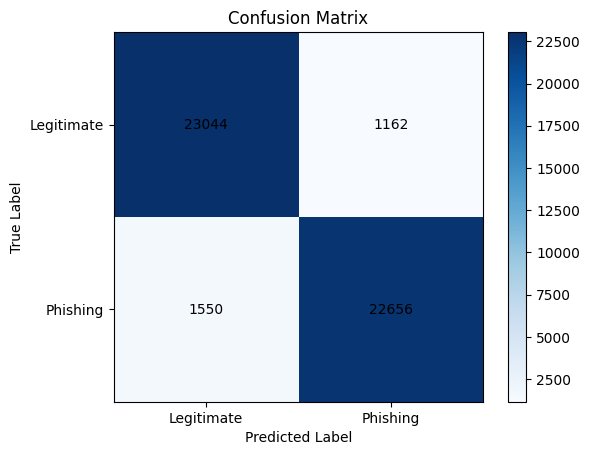

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure()

# Use default blue colormap
plt.imshow(cm, cmap='Blues')

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

# Axis labels
plt.xticks([0, 1], ["Legitimate", "Phishing"])
plt.yticks([0, 1], ["Legitimate", "Phishing"])

# Add values inside cells
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j],
                 ha='center', va='center')

# Add color bar (important for visualization)
plt.colorbar()

plt.show()

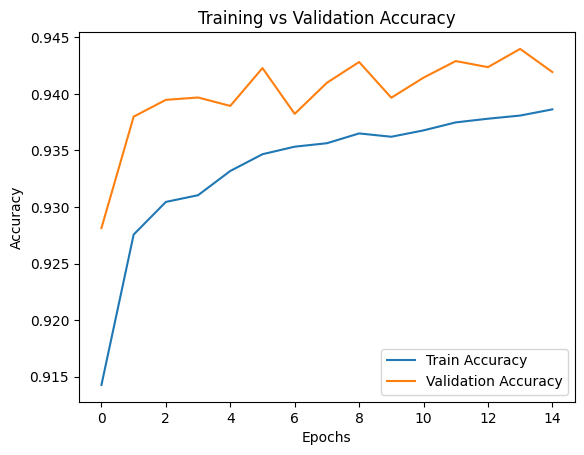

In [ ]:
import matplotlib.pyplot as plt

# Plot accuracy
plt.figure()

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Training vs Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")

plt.legend(["Train Accuracy", "Validation Accuracy"])

plt.show()

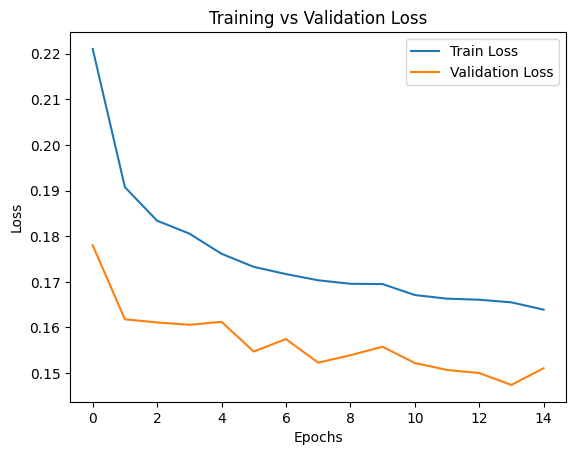

In [ ]:
plt.figure()

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title("Training vs Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")

plt.legend(["Train Loss", "Validation Loss"])

plt.show()